# **Preprocessing**

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# 1. Mount Drive
drive.mount('/content/drive')

# 2. Path Dataset
image_path = "/content/drive/MyDrive/dataset/Images"
excel_path = "/content/drive/MyDrive/dataset/Subjective Analysis/MAV-UIDLEIA.xlsx"

# 3. Load MAV (Mean Acceptance Value)
try:
    df_mav = pd.read_excel(excel_path)
except:
    # Backup jika file dalam format csv
    df_mav = pd.read_csv(excel_path.replace('.xlsx', '.csv'))

df_mav['Image File Name'] = df_mav['Image File Name'].str.strip()
mav_dict = dict(zip(df_mav['Image File Name'], df_mav['MAV']))

print("Tahap 1 Selesai: Koneksi Drive dan Label MAV berhasil dimuat.")

Mounted at /content/drive
Tahap 1 Selesai: Koneksi Drive dan Label MAV berhasil dimuat.


In [ ]:
# Cek jumlah nilai MAV yang unik
jumlah_unik = df_mav['MAV'].nunique()
print(f"Terdapat {jumlah_unik} nilai MAV unik dari total {len(df_mav)} data.")

Terdapat 135 nilai MAV unik dari total 135 data.


# **Ekstraksi Fitur (Preprocessing & Feature Extraction)**

In [ ]:
from skimage.feature import graycomatrix, graycoprops

data_features = []
target_mav = []

print("Memulai Ekstraksi Fitur...")

for file in os.listdir(image_path):
    if not file.lower().endswith(('.jpg', '.png', '.jpeg')): continue

    filename_clean = file.replace(".jpg", "").replace(".png", "").strip()
    mav_value = mav_dict.get(filename_clean)
    if mav_value is None: continue

    # Load & Standarisasi Ukuran
    img = cv2.imread(os.path.join(image_path, file))
    img_res = cv2.resize(img, (128, 128))

    # A. Fitur Warna (RGB & HSV)
    mean_rgb = img_res.mean(axis=(0,1))
    hsv = cv2.cvtColor(img_res, cv2.COLOR_BGR2HSV)
    mean_hsv = hsv.mean(axis=(0,1))

    # B. Fitur Tekstur (GLCM)
    gray = cv2.cvtColor(img_res, cv2.COLOR_BGR2GRAY)
    glcm = graycomatrix(gray, [1], [0], 256, symmetric=True, normed=True)
    contrast = graycoprops(glcm, 'contrast')[0, 0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]

    # Gabungkan Fitur
    data_features.append([mean_rgb[2], mean_rgb[1], mean_rgb[0],
                         mean_hsv[0], mean_hsv[1], mean_hsv[2],
                         contrast, homogeneity])
    target_mav.append(mav_value)

print(f"Tahap 2 Selesai: {len(data_features)} gambar berhasil diekstrak fiturnya.")

Memulai Ekstraksi Fitur...
Tahap 2 Selesai: 135 gambar berhasil diekstrak fiturnya.


# **Normalisasi dan Pembagian Data**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = np.array(data_features)
y = np.array(target_mav)

# Normalisasi (Z-Score Scaling)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"Tahap 3 Selesai: Data Training ({len(X_train)}) dan Testing ({len(X_test)}) siap.")

Tahap 3 Selesai: Data Training (108) dan Testing (27) siap.


# **Perbandingan Multi-Model Regresi**

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Inisialisasi Model berdasarkan Referensi Jurnal
models = {
    "Random Forest (Jurnal 1)": RandomForestRegressor(n_estimators=100, random_state=42),
    "Neural Network / ANN (Jurnal 2)": MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=2000, random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Hitung Metrik
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    results.append({"Metode": name, "R2 Score": r2, "MAE": mae})

df_hasil = pd.DataFrame(results)
print("\n=== PERBANDINGAN METODE TERBAIK DARI JURNAL ===")
print(df_hasil)


=== PERBANDINGAN METODE TERBAIK DARI JURNAL ===
                            Metode  R2 Score       MAE
0         Random Forest (Jurnal 1)  0.853747  7.554411
1  Neural Network / ANN (Jurnal 2)  0.900843  5.705108


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


# **Evaluasi & Visualisasi**

/tmp/ipykernel_906/3174874879.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Metode", y="R2 Score", data=df_hasil, palette="coolwarm")


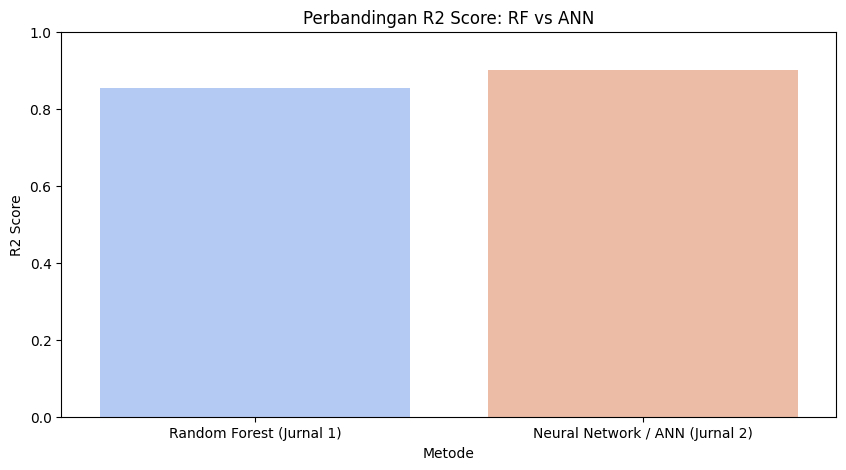

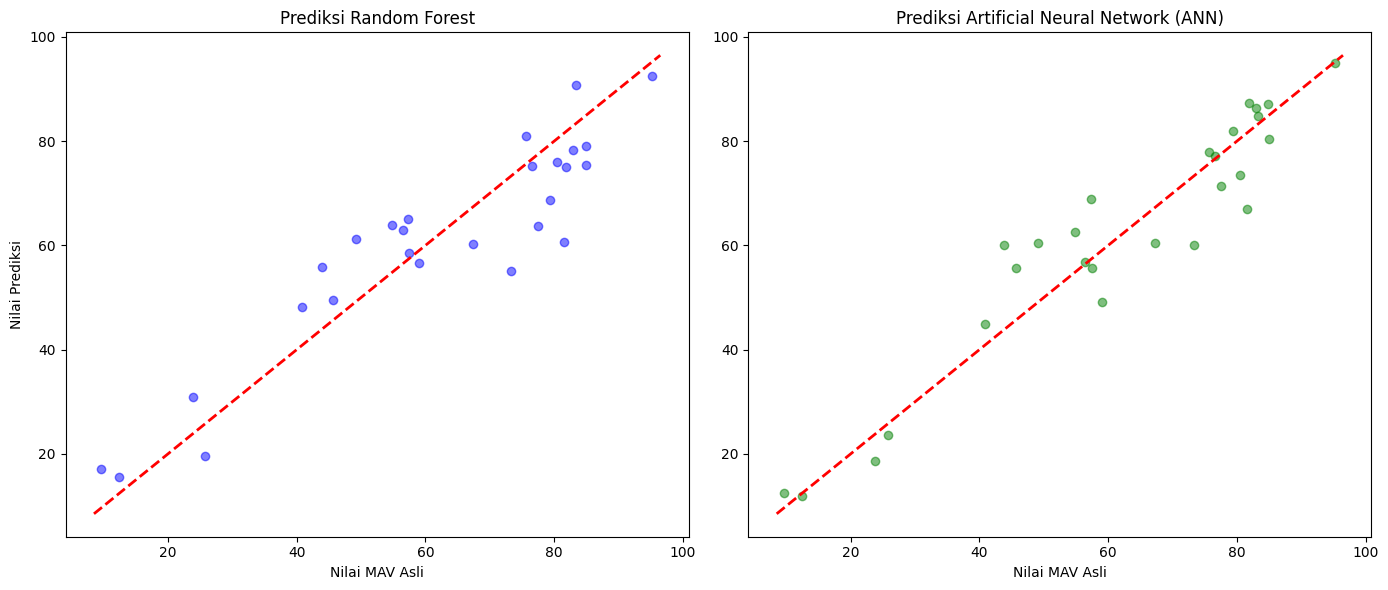


Tahap 5 Selesai: Model siap dibandingkan untuk mendukung target SDG 6.


In [ ]:
# 1. Bar Plot Perbandingan R2 Score
plt.figure(figsize=(10, 5))
sns.barplot(x="Metode", y="R2 Score", data=df_hasil, palette="coolwarm")
plt.title("Perbandingan R2 Score: RF vs ANN")
plt.ylim(0, 1)
plt.show()

# 2. Scatter Plot Kesesuaian Prediksi
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot Random Forest
rf_pred = models["Random Forest (Jurnal 1)"].predict(X_test)
ax1.scatter(y_test, rf_pred, color='blue', alpha=0.5)
ax1.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
ax1.set_title("Prediksi Random Forest")
ax1.set_xlabel("Nilai MAV Asli")
ax1.set_ylabel("Nilai Prediksi")

# Plot ANN
ann_pred = models["Neural Network / ANN (Jurnal 2)"].predict(X_test)
ax2.scatter(y_test, ann_pred, color='green', alpha=0.5)
ax2.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
ax2.set_title("Prediksi Artificial Neural Network (ANN)")
ax2.set_xlabel("Nilai MAV Asli")

plt.tight_layout()
plt.show()

print("\nTahap 5 Selesai: Model siap dibandingkan untuk mendukung target SDG 6.")

Memulai Eksperimen Pengaruh Fitur...

=== PENGARUH FEATURE EXTRACTION TERHADAP AKURASI ===
                Skenario  R2 Score
1              Tanpa RGB  0.864469
0  Semua Fitur (Lengkap)  0.853747
2              Tanpa HSV  0.787887
3   Tanpa GLCM (Tekstur)  0.395709


/tmp/ipykernel_906/1031991981.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="R2 Score", y="Skenario", data=df_ablation.sort_values(by="R2 Score", ascending=False), palette="magma")


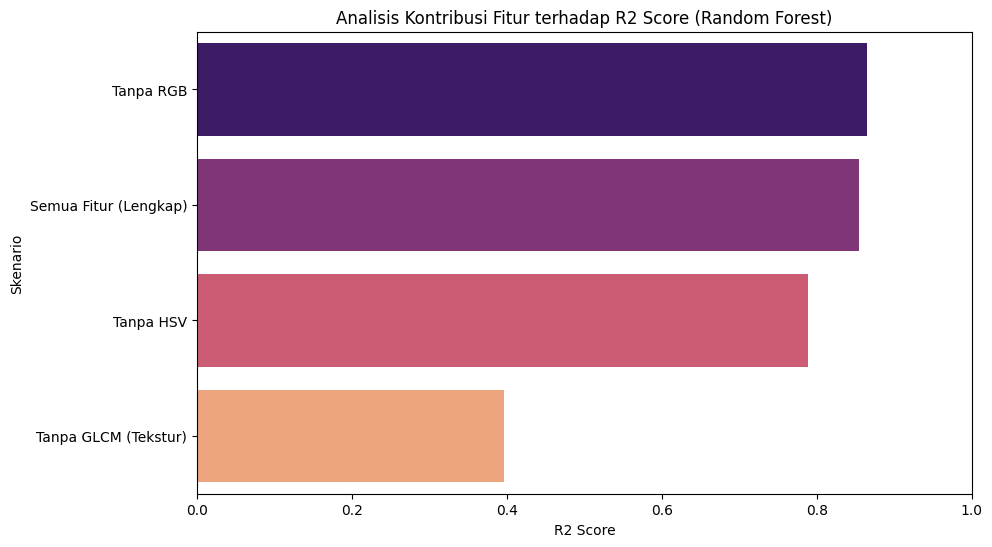

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Definisikan indeks kolom untuk setiap grup fitur
# Urutan di Tahap 2: [R(0), G(1), B(2), H(3), S(4), V(5), Contrast(6), Homogeneity(7)]
feature_groups = {
    "Semua Fitur (Lengkap)": [0, 1, 2, 3, 4, 5, 6, 7],
    "Tanpa RGB": [3, 4, 5, 6, 7],
    "Tanpa HSV": [0, 1, 2, 6, 7],
    "Tanpa GLCM (Tekstur)": [0, 1, 2, 3, 4, 5]
}

ablation_results = []
model_test = RandomForestRegressor(n_estimators=100, random_state=42)

print("Memulai Eksperimen Pengaruh Fitur...")

for name, indices in feature_groups.items():
    # Pilih hanya kolom fitur yang ditentukan
    X_train_sub = X_train[:, indices]
    X_test_sub = X_test[:, indices]

    # Latih model
    model_test.fit(X_train_sub, y_train)
    y_pred = model_test.predict(X_test_sub)

    # Hitung R2 Score
    r2 = r2_score(y_test, y_pred)
    ablation_results.append({"Skenario": name, "R2 Score": r2})

# Tampilkan Hasil
df_ablation = pd.DataFrame(ablation_results)
print("\n=== PENGARUH FEATURE EXTRACTION TERHADAP AKURASI ===")
print(df_ablation.sort_values(by="R2 Score", ascending=False))

# Visualisasi
plt.figure(figsize=(10, 6))
sns.barplot(x="R2 Score", y="Skenario", data=df_ablation.sort_values(by="R2 Score", ascending=False), palette="magma")
plt.title("Analisis Kontribusi Fitur terhadap R2 Score (Random Forest)")
plt.xlim(0, 1)
plt.show()

Memulai Eksperimen Pengaruh Fitur pada ANN...


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(



=== PENGARUH FEATURE EXTRACTION TERHADAP AKURASI ANN ===
                Skenario  R2 Score
0  Semua Fitur (Lengkap)  0.900843
1              Tanpa RGB  0.898384
2              Tanpa HSV  0.846597
3   Tanpa GLCM (Tekstur)  0.636586


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
/tmp/ipykernel_906/2882415687.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="R2 Score", y="Skenario", data=df_ann_ablation.sort_values(by="R2 Score", ascending=False), palette="viridis")


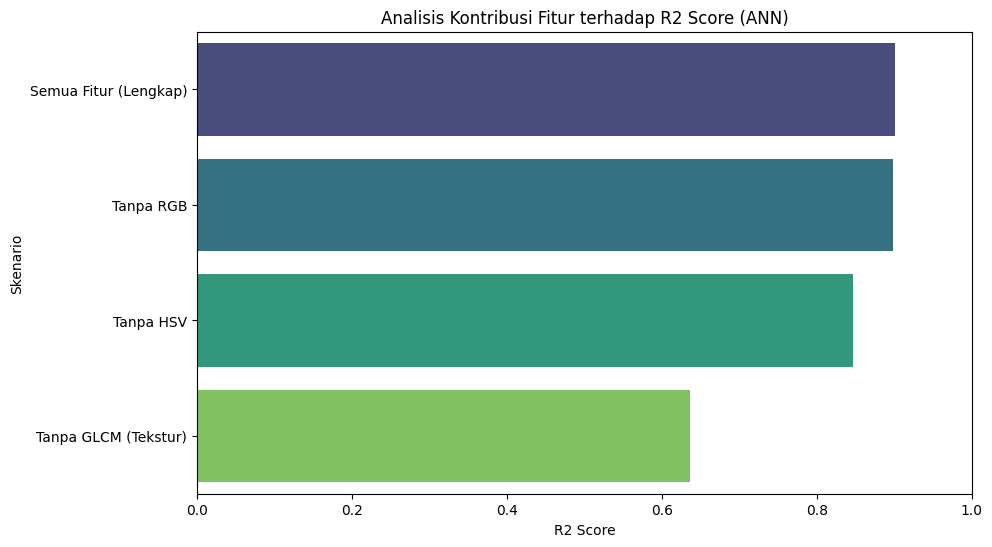

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score

# Definisikan indeks kolom [R(0), G(1), B(2), H(3), S(4), V(5), Contrast(6), Homogeneity(7)]
feature_groups = {
    "Semua Fitur (Lengkap)": [0, 1, 2, 3, 4, 5, 6, 7],
    "Tanpa RGB": [3, 4, 5, 6, 7],
    "Tanpa HSV": [0, 1, 2, 6, 7],
    "Tanpa GLCM (Tekstur)": [0, 1, 2, 3, 4, 5]
}

ann_ablation_results = []
# Menggunakan parameter yang sama dengan tahap sebelumnya
model_ann_test = MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=2000, random_state=42)

print("Memulai Eksperimen Pengaruh Fitur pada ANN...")

for name, indices in feature_groups.items():
    X_train_sub = X_train[:, indices]
    X_test_sub = X_test[:, indices]

    model_ann_test.fit(X_train_sub, y_train)
    y_pred = model_ann_test.predict(X_test_sub)

    r2 = r2_score(y_test, y_pred)
    ann_ablation_results.append({"Skenario": name, "R2 Score": r2})

# Tampilkan Hasil
df_ann_ablation = pd.DataFrame(ann_ablation_results)
print("\n=== PENGARUH FEATURE EXTRACTION TERHADAP AKURASI ANN ===")
print(df_ann_ablation.sort_values(by="R2 Score", ascending=False))

# Visualisasi
plt.figure(figsize=(10, 6))
sns.barplot(x="R2 Score", y="Skenario", data=df_ann_ablation.sort_values(by="R2 Score", ascending=False), palette="viridis")
plt.title("Analisis Kontribusi Fitur terhadap R2 Score (ANN)")
plt.xlim(0, 1)
plt.show()